# Volatility Modelling

In [1]:
import numpy as np
import pandas as pd
import pickle
import scipy.stats as stats
from arch import arch_model
from matplotlib import pyplot as plt

import sys
sys.path.append("../src")
from risklib.plot_utils import shade_regimes

In [40]:
# Load return data
returns = pd.read_csv("../data/returns.csv", parse_dates=[0], index_col=0)

columns = returns.columns
weights = np.array([0.25, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10])

## 1. Baseline Volatility

- **Moving Average**
- **EWMA (RiskMetrics)**

### Moving Average (MA)

The Moving Average method is the most naive way to estimate volatility, we use it as a baseline model for downstream comparison (while estimating VaR and ES) with other more sophisticated methods.

We can observe that:
1. Besides the house market crash during 2008-2009, VNQ also had a volatility spike during the 2020 Covid market crash like SPY/QQQ despite being considered a "real asset".
2. Treasury bonds (IEF/TLT) bahaves in an unexpected way during 2022, when the market is not crashing, which in consensus should serve as a "safe haven" when equity volatility spikes.

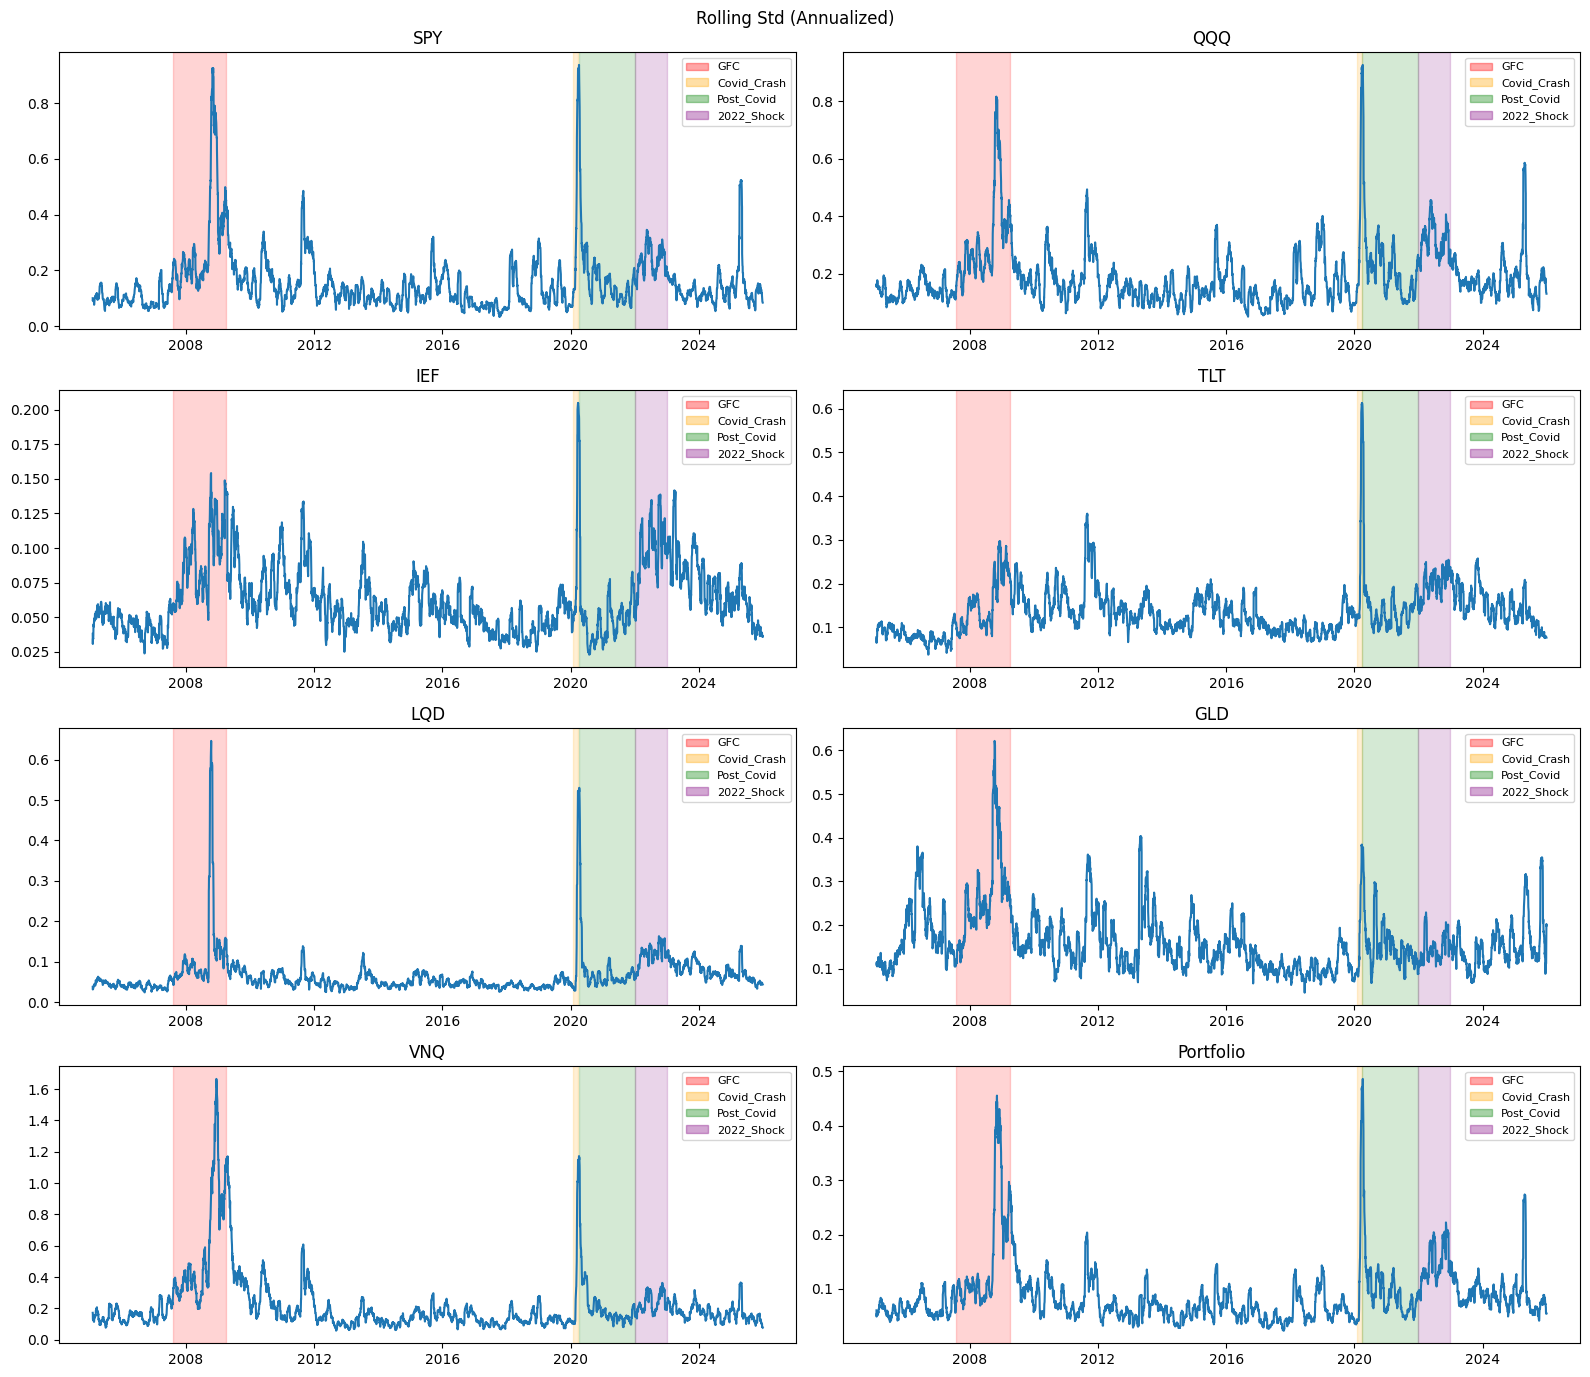

In [41]:
# Rolling std
window = 21   # Results are sensitive to window length

roll_std = returns.rolling(window).std() * np.sqrt(252)  # annualized volatility

fig, ax = plt.subplots(4,2, figsize=(16,14))
for i,a in enumerate(ax.flat):
    a.plot(roll_std[columns[i]])
    a.set_title(f"{columns[i]}")
    handles = shade_regimes(a)
    a.legend(handles=handles, fontsize=8)
plt.suptitle("Rolling Std (Annualized)")
plt.tight_layout()

### EWMA

EWMA is a speacial case of $GARCH(1,1)$, setting $\lambda = 0.94$ (JP Morgan convention), meaning 94% of the previous day is preserved. However, since it 

Observation:
1. Compared to Moving Average, rolling EWMA fluctuates less since it preserves information of the previous day.

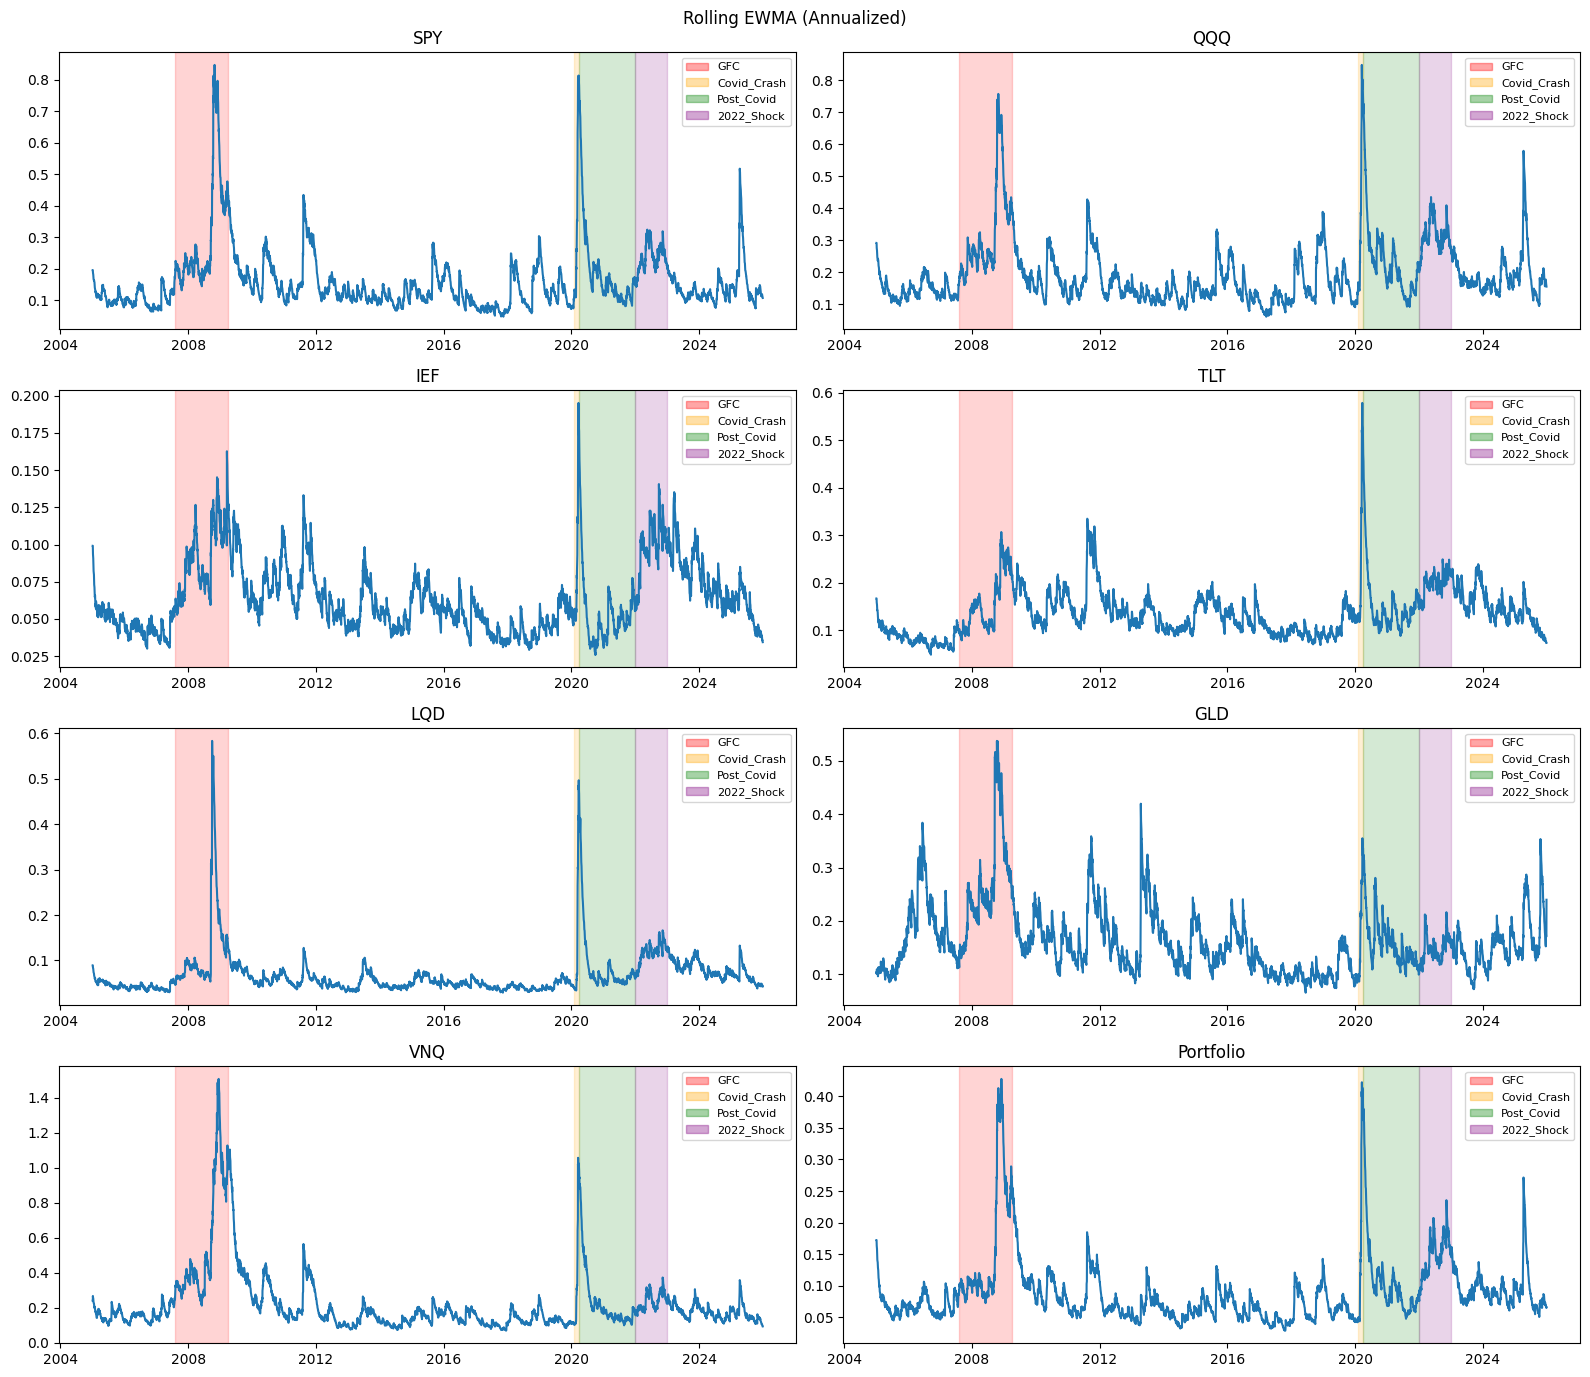

In [42]:
def ewma_vol(returns_series, lam=0.94):
    r = returns_series.dropna()
    variance = np.zeros(len(r))
    variance[0] = r.iloc[0]**2

    for t in range(1, len(r)):
        variance[t] = lam * variance[t-1] + (1 - lam) * r.iloc[t-1]**2

    vol = pd.Series(np.sqrt(variance) * np.sqrt(252),
                    index=r.index,
                    name=returns_series.name)
    return vol

roll_ewma = pd.DataFrame({
    col: ewma_vol(returns[col]) for col in columns
})

fig, ax = plt.subplots(4,2, figsize=(16,14))
for i,a in enumerate(ax.flat):
    a.plot(roll_ewma[columns[i]])
    a.set_title(f"{columns[i]}")
    handles = shade_regimes(a)
    a.legend(handles=handles, fontsize=8)
plt.suptitle("Rolling EWMA (Annualized)")
plt.tight_layout()

### Comparison

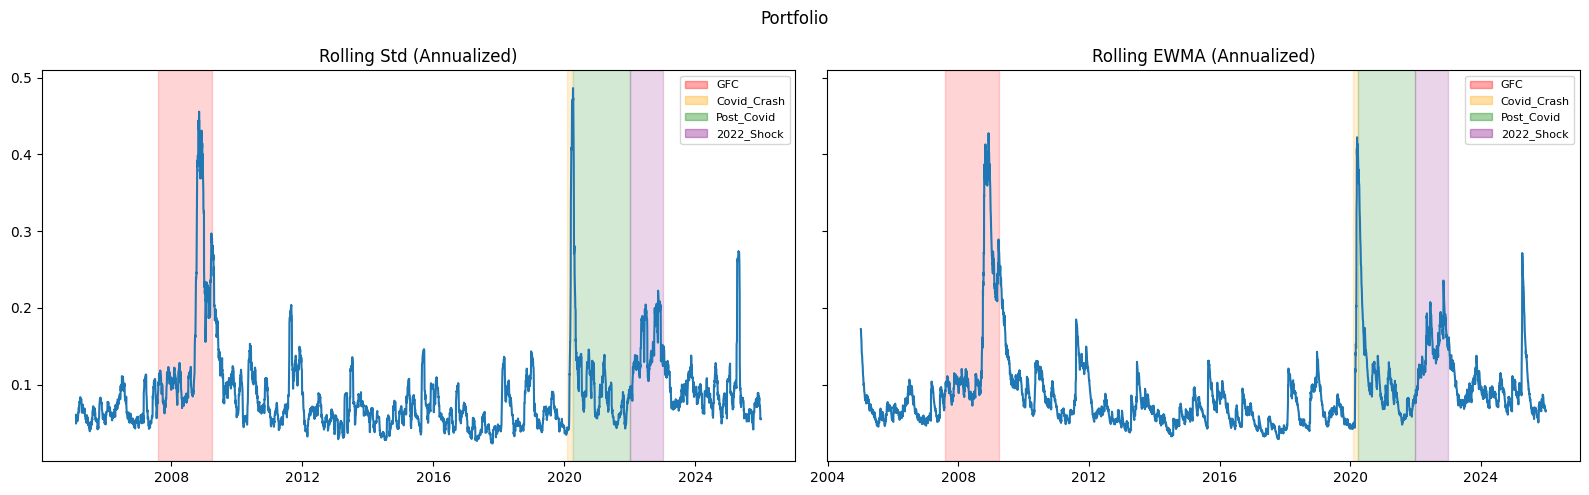

In [43]:
# Plot SPY volatility estimated by rolling std and EWMA
fig, ax = plt.subplots(1,2, figsize=(16,5), sharey=True)
ax[0].plot(roll_std.Portfolio)
ax[1].plot(roll_ewma.Portfolio)
ax[0].set_title("Rolling Std (Annualized)")
ax[1].set_title("Rolling EWMA (Annualized)")
handles_0 = shade_regimes(ax[0])
handles_1 = shade_regimes(ax[1])
ax[0].legend(handles=handles, fontsize=8)
ax[1].legend(handles=handles, fontsize=8)
plt.suptitle("Portfolio")
plt.tight_layout()

## 2. GARCH(1,1) model

GARCH(1,1) formula: $$\sigma_{t}^2 = \omega + \alpha\epsilon_{t-1}^2 + \beta\sigma_{t-1}^2$$

- $\omega$ : long term mean average
- $\alpha$ : sensitivity - reaction to the previous return (or loss)
- $\beta$ : persistence - how slow the volatility decays under normal conditions
- **Unconditional variance**:
  \begin{equation}
  \sigma^2 = \frac{\omega}{1-\alpha-\beta} \ \ \text{where} \ \ \alpha + \beta < 1
  \end{equation}

In [74]:
# Fit GARCH(1,1) for all asset losses
# Using Student-t distribution assumption to capture fat tails

returns_scaled = returns * 1000   # Scale up for numerical stability during GARCH model fitting

garch_res = {}
garch_params = {}
garch_cond_vol = {}

for col in columns:
    model = arch_model(returns_scaled[col], mean="Constant", vol="GARCH", p=1, q=1, dist="StudentsT")
    res = model.fit(disp="off", show_warning=False)
    # Store results
    garch_res[col] = res
    garch_params[col] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'beta': res.params['beta[1]'],
        'nu': res.params['nu'],  # degree of freedom of Student's T
        'persistence': res.params['alpha[1]'] + res.params['beta[1]'],
        'uncond_vol': np.sqrt(res.params['omega'] / (1 - res.params['alpha[1]'] - res.params['beta[1]'])) / 1000, # rescaled
    }
    garch_cond_vol[col] = res.conditional_volatility / 1000   # rescaled

garch_cond_vol = pd.DataFrame(garch_cond_vol)

In [75]:
# GARCH(1,1) Paramater Table
params_df = pd.DataFrame(garch_params).T
print("GARCH(1,1) model parameters:")
print(params_df.round(4).to_string())

GARCH(1,1) model parameters:
            omega   alpha    beta       nu  persistence  uncond_vol
SPY        1.9205  0.1447  0.8500   5.4044       0.9947      0.0191
QQQ        2.8105  0.1198  0.8711   5.9308       0.9909      0.0176
IEF        0.1179  0.0527  0.9412  12.8047       0.9939      0.0044
TLT        0.4934  0.0527  0.9419  15.8265       0.9946      0.0096
LQD        0.2868  0.0783  0.9060   8.2780       0.9843      0.0043
GLD        0.9252  0.0456  0.9482   5.3649       0.9939      0.0123
VNQ        2.0266  0.1015  0.8906   7.8316       0.9920      0.0159
Portfolio  0.4556  0.0977  0.8927   6.7169       0.9904      0.0069


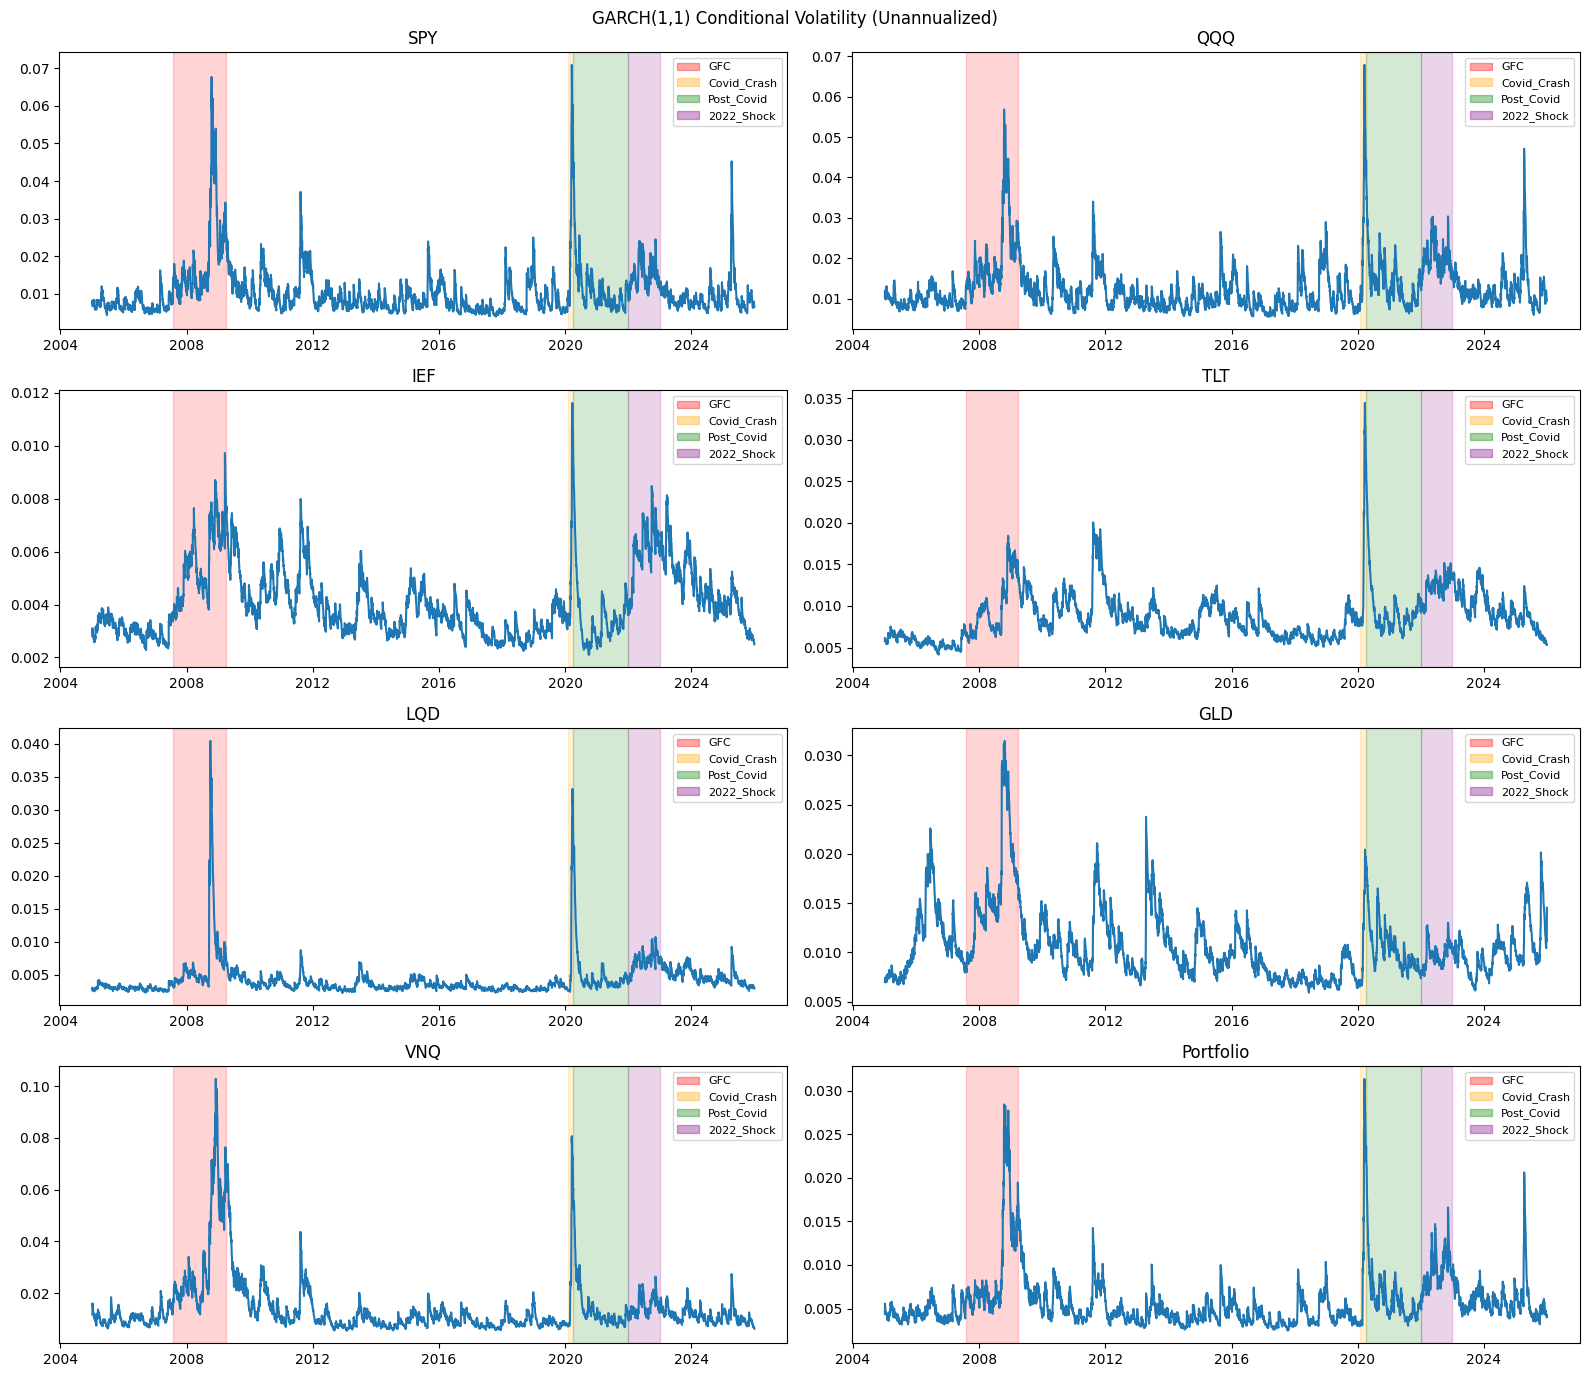

In [76]:
# Plot GARCH(1,1) fitted conditional volatility
fig, ax = plt.subplots(4,2, figsize=(16,14))
for i,a in enumerate(ax.flat):
    a.plot(garch_cond_vol[columns[i]])
    a.set_title(f"{columns[i]}")
    handles = shade_regimes(a)
    a.legend(handles=handles, fontsize=8)
plt.suptitle("GARCH(1,1) Conditional Volatility (Unannualized)")
plt.tight_layout()

### Observation

1. We can see that all assets have persistence near 1, which means every asset in this portfolio has **volatility clustering** phenomena.
2. SPY/QQQ/VNQ (Equity & REIT) has higher alpha than IEF/TLT/LQD/GLD (Treasury bonds, Corporate credit, Gold), which means they react more to new shocks.

## 3. Considering Leverage Effects

Leverage effect is the effect when borrowed debt amplifies the return of equities, which also amplifies the risk of equity returns because debt itself contains other risks. In order to capture these extra risk, we can use a modified GARCH model called **GJR-GARCH**:

$$\sigma_{t}^2 = \omega + (\alpha+\gamma I_{t-1})\epsilon_{t-1}^2 + \beta\sigma_{t-1}^2$$

where $I_{t-1} = 1$ when $\epsilon_{t-1} < 0$ (bad news) and 0 otherwise. Thus, we have an additional effect when there is negative return on the previous day.

In [77]:
# Fit GJR-GARCH(1,1) for all asset losses
# Using Student-t distribution assumption to capture fat tails
leverage_assets = ['SPY', 'QQQ', 'VNQ']

gjr_res = {}
gjr_params = {}
gjr_cond_vol = {}

for ticker in leverage_assets:
    model = arch_model(returns_scaled[ticker], mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="StudentsT")
    res = model.fit(disp="off", show_warning=False)
    # Store results
    gjr_res[ticker] = res
    gjr_params[ticker] = {
        'omega': res.params['omega'],
        'alpha': res.params['alpha[1]'],
        'gamma': res.params['gamma[1]'],
        'beta': res.params['beta[1]'],
        'gamma_tval': res.tvalues['gamma[1]'],
        'gamma_pval': res.pvalues['gamma[1]'],
        'nu': res.params['nu'],  # degree of freedom of Student's T
        'persistence': res.params['alpha[1]'] + res.params['beta[1]'],
        'uncond_vol': np.sqrt(res.params['omega'] / (1 - res.params['alpha[1]'] - res.params['beta[1]'])) / 1000, # rescaled
    }
    gjr_cond_vol[ticker] = res.conditional_volatility / 1000  # rescaled

gjr_cond_vol = pd.DataFrame(gjr_cond_vol)

In [78]:
# GJR-GARCH(1,1) Paramater Table
gjr_params_df = pd.DataFrame(gjr_params).T
print("GJR-GARCH(1,1) model parameters:")
print(gjr_params_df.round(4).to_string())

GJR-GARCH(1,1) model parameters:
      omega   alpha   gamma    beta  gamma_tval  gamma_pval      nu  persistence  uncond_vol
SPY  2.2628  0.0000  0.2480  0.8566      9.0047         0.0  5.8269       0.8566      0.0040
QQQ  3.5519  0.0000  0.2049  0.8733      8.4990         0.0  6.3909       0.8733      0.0053
VNQ  2.0808  0.0499  0.0791  0.8983      5.0461         0.0  8.0643       0.9482      0.0063


We can see that the estimated gammas of all equity assets are significant.

### Comparison with GARCH(1,1)

From the following plot we can observe that the difference in unconditional volatility is most visible after large moves of the return, and the GJR-GARCH model gives more reserved estimation during these times.

We also plot a News Impact Curve to visualize the asymmetry of the GJR-GARCH model.

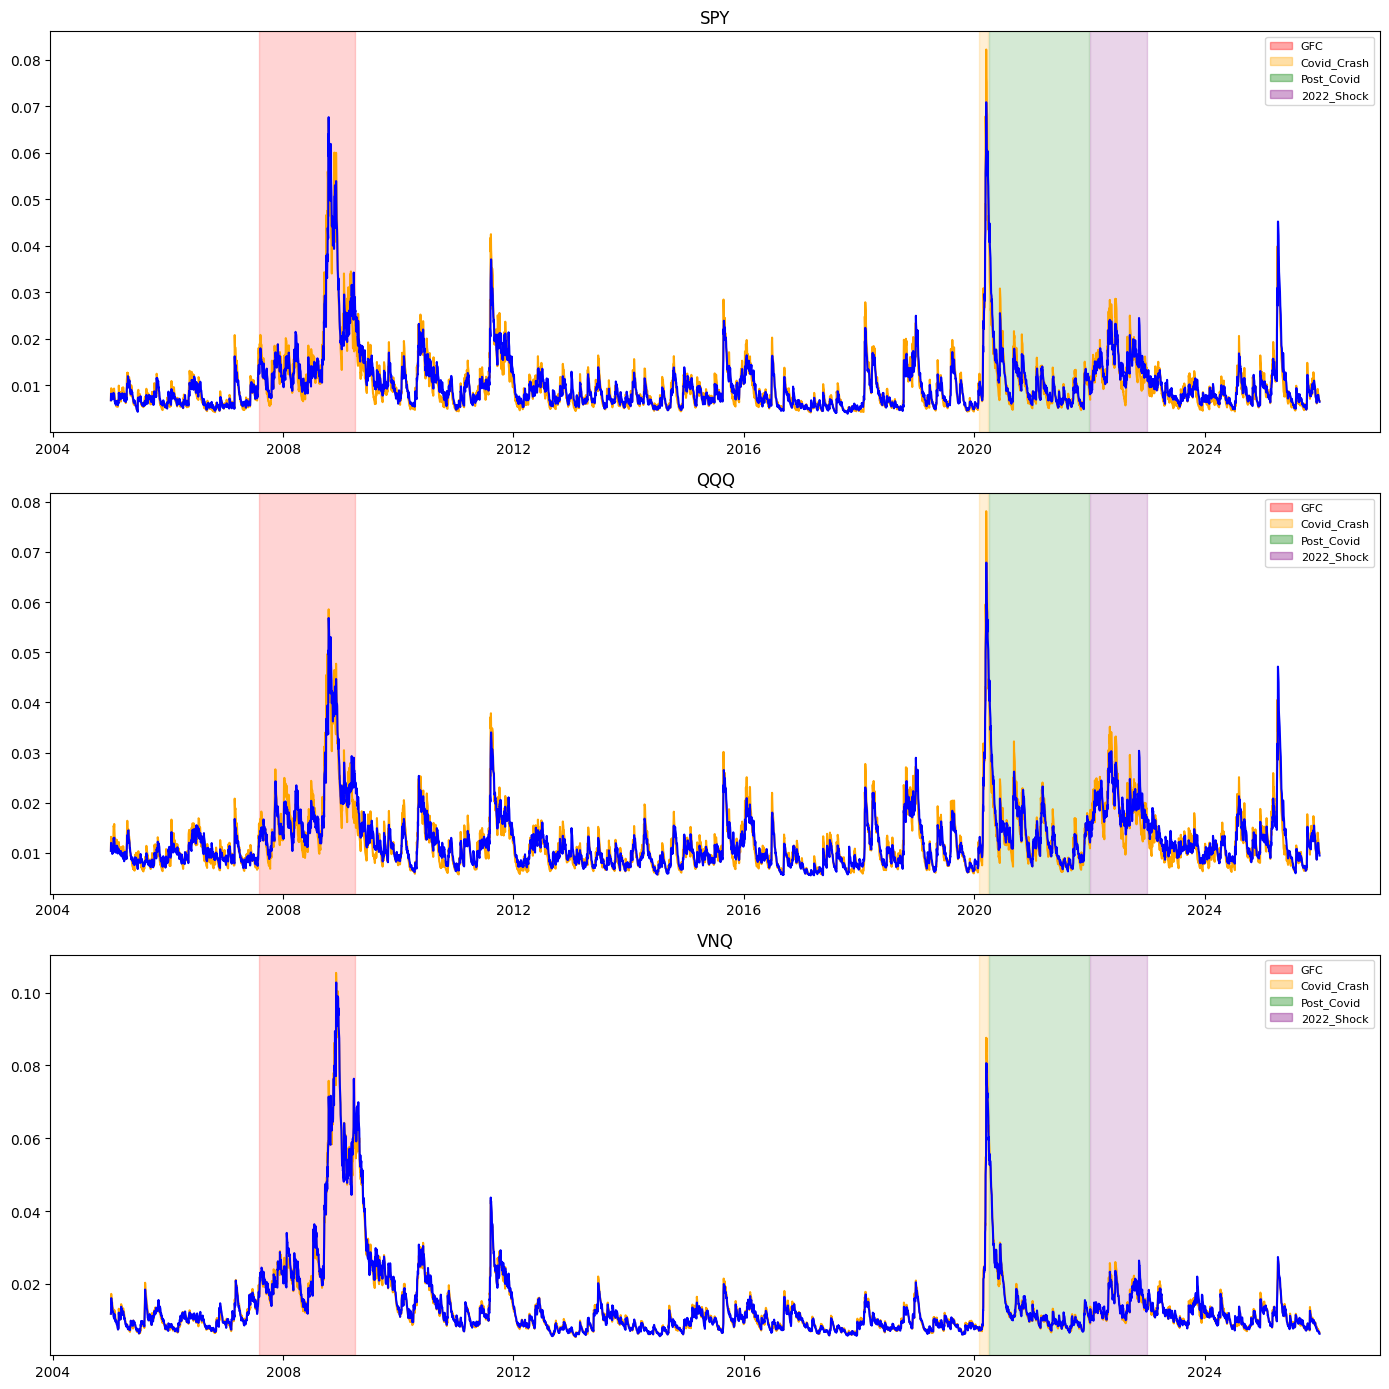

In [79]:
# Plot GJR-GARCH and GARCH fitted unconditional volatility of leveraged assets
fig, ax = plt.subplots(len(leverage_assets),1, figsize=(14,14))
for i,ticker in enumerate(leverage_assets):
    ax[i].plot(gjr_cond_vol[ticker], label="GJR-GARCH", color='orange')
    ax[i].plot(garch_cond_vol[ticker], label="GARCH", color='blue')
    ax[i].legend()
    ax[i].set_title(f"{ticker}")
    handles = shade_regimes(ax[i])
    ax[i].legend(handles=handles, fontsize=8)
    
plt.tight_layout()

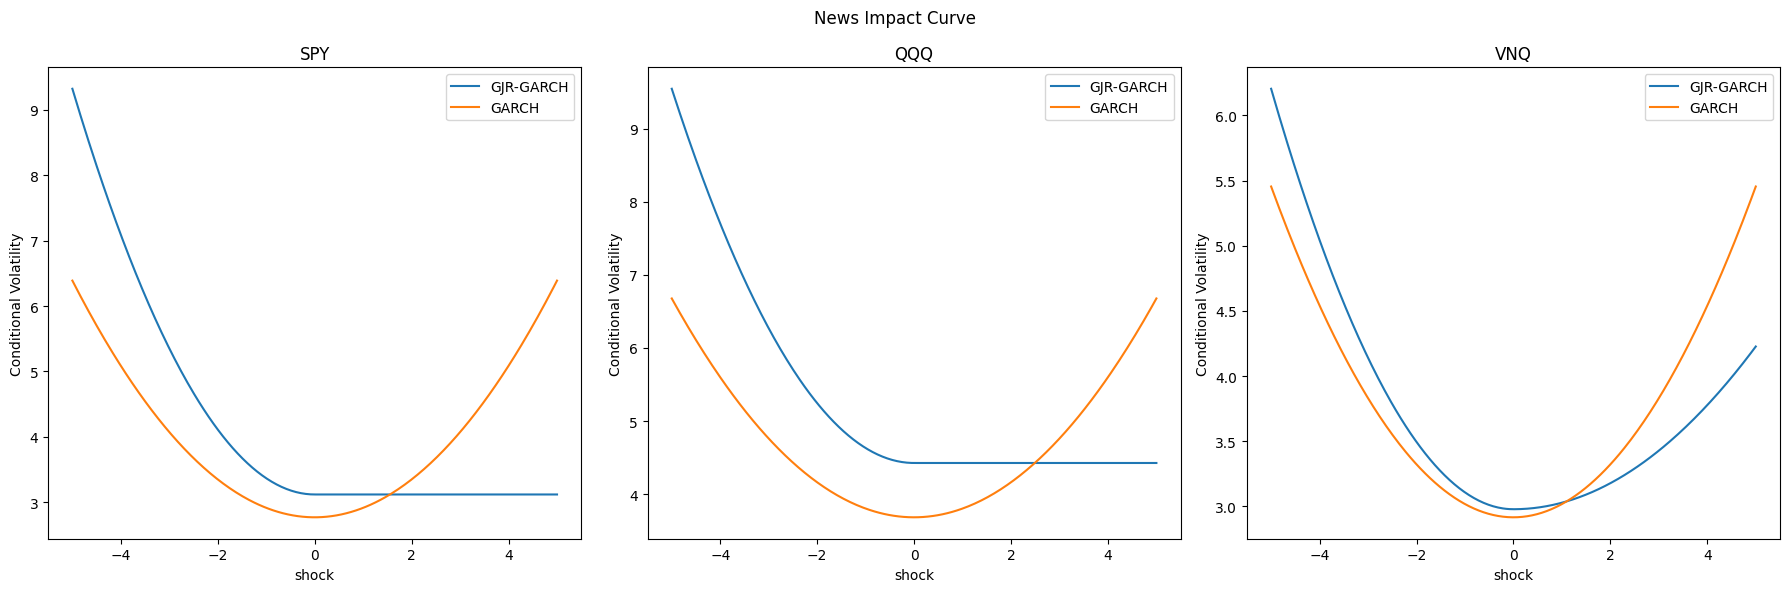

In [80]:
# News impact curve
fig, ax = plt.subplots(1,3, figsize=(18,6))
for i,ticker in enumerate(leverage_assets):
    shocks = np.linspace(-5,5,300)
    # GJR-GARCH
    p_gjr = gjr_params[ticker]
    indicator = (shocks < 0).astype(float)
    nic_gjr = p_gjr['omega'] + (p_gjr['alpha']+p_gjr['gamma']*indicator) * shocks**2 + p_gjr['beta']*1.0
    # GARCH
    p_garch = garch_params[ticker]
    nic_garch = p_garch['omega'] + p_garch['alpha'] * shocks**2 + p_garch['beta']*1.0
    # Plot new impact curve
    ax[i].plot(shocks, nic_gjr, label="GJR-GARCH")
    ax[i].plot(shocks, nic_garch, label="GARCH")
    ax[i].legend()
    ax[i].set_xlabel("shock")
    ax[i].set_ylabel("Conditional Volatility")
    ax[i].set_title(f"{ticker}")
    
plt.suptitle("News Impact Curve")
plt.tight_layout()

We can see that after fitting GJR-GARCH
1. SPY/QQQ exhibits extreme assymetric behavior, since $\alpha$ is pushed to nearly zero, which means positive shocks ($\alpha$) have far less impact on volatility compared to negative shocks ($\gamma$) -> strong leverage effect
2. VNQ is less prone to leverage effect than SPY/QQQ

## 4. Diagnostics

### Standardized Residuals

Use Ljung-Box Test and ACF plots to check if standardized residuals after fitting GARCH are autocorrelated or not.

In [81]:
# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox

tested_res = garch_res

for col in tested_res.keys():
    res = tested_res[col]
    std_resid = res.std_resid.dropna()    # standardized residual
    lb_resid = acorr_ljungbox(std_resid, lags=[5, 10, 20], return_df=True)     # ljung-box test on "residuals"
    lb_square = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True) # ljung-box test on "squared residuals"

    print(f"{"="*60}")
    print(f"{col} — Ljung-Box on Residuals (H0: no autocorrelation)")
    print(lb_resid[['lb_stat', 'lb_pvalue']].to_string())
    print(f"\n{col} — Ljung-Box on Squared Residuals (H0: no ARCH effects)")
    print(lb_square[['lb_stat', 'lb_pvalue']].to_string())

SPY — Ljung-Box on Residuals (H0: no autocorrelation)
      lb_stat  lb_pvalue
5   11.808561   0.037507
10  18.214194   0.051456
20  30.122727   0.067889

SPY — Ljung-Box on Squared Residuals (H0: no ARCH effects)
      lb_stat  lb_pvalue
5    4.253767   0.513488
10  11.453207   0.323315
20  21.253491   0.382350
QQQ — Ljung-Box on Residuals (H0: no autocorrelation)
      lb_stat  lb_pvalue
5    5.492304   0.358790
10  14.073468   0.169667
20  24.410654   0.224914

QQQ — Ljung-Box on Squared Residuals (H0: no ARCH effects)
      lb_stat  lb_pvalue
5    4.418481   0.490864
10   9.331265   0.500980
20  26.220968   0.158637
IEF — Ljung-Box on Residuals (H0: no autocorrelation)
      lb_stat  lb_pvalue
5    9.067533   0.106401
10  12.701786   0.240826
20  21.486308   0.369022

IEF — Ljung-Box on Squared Residuals (H0: no ARCH effects)
      lb_stat  lb_pvalue
5    6.713306   0.242850
10   8.921986   0.539523
20  26.668073   0.144863
TLT — Ljung-Box on Residuals (H0: no autocorrelation)
    

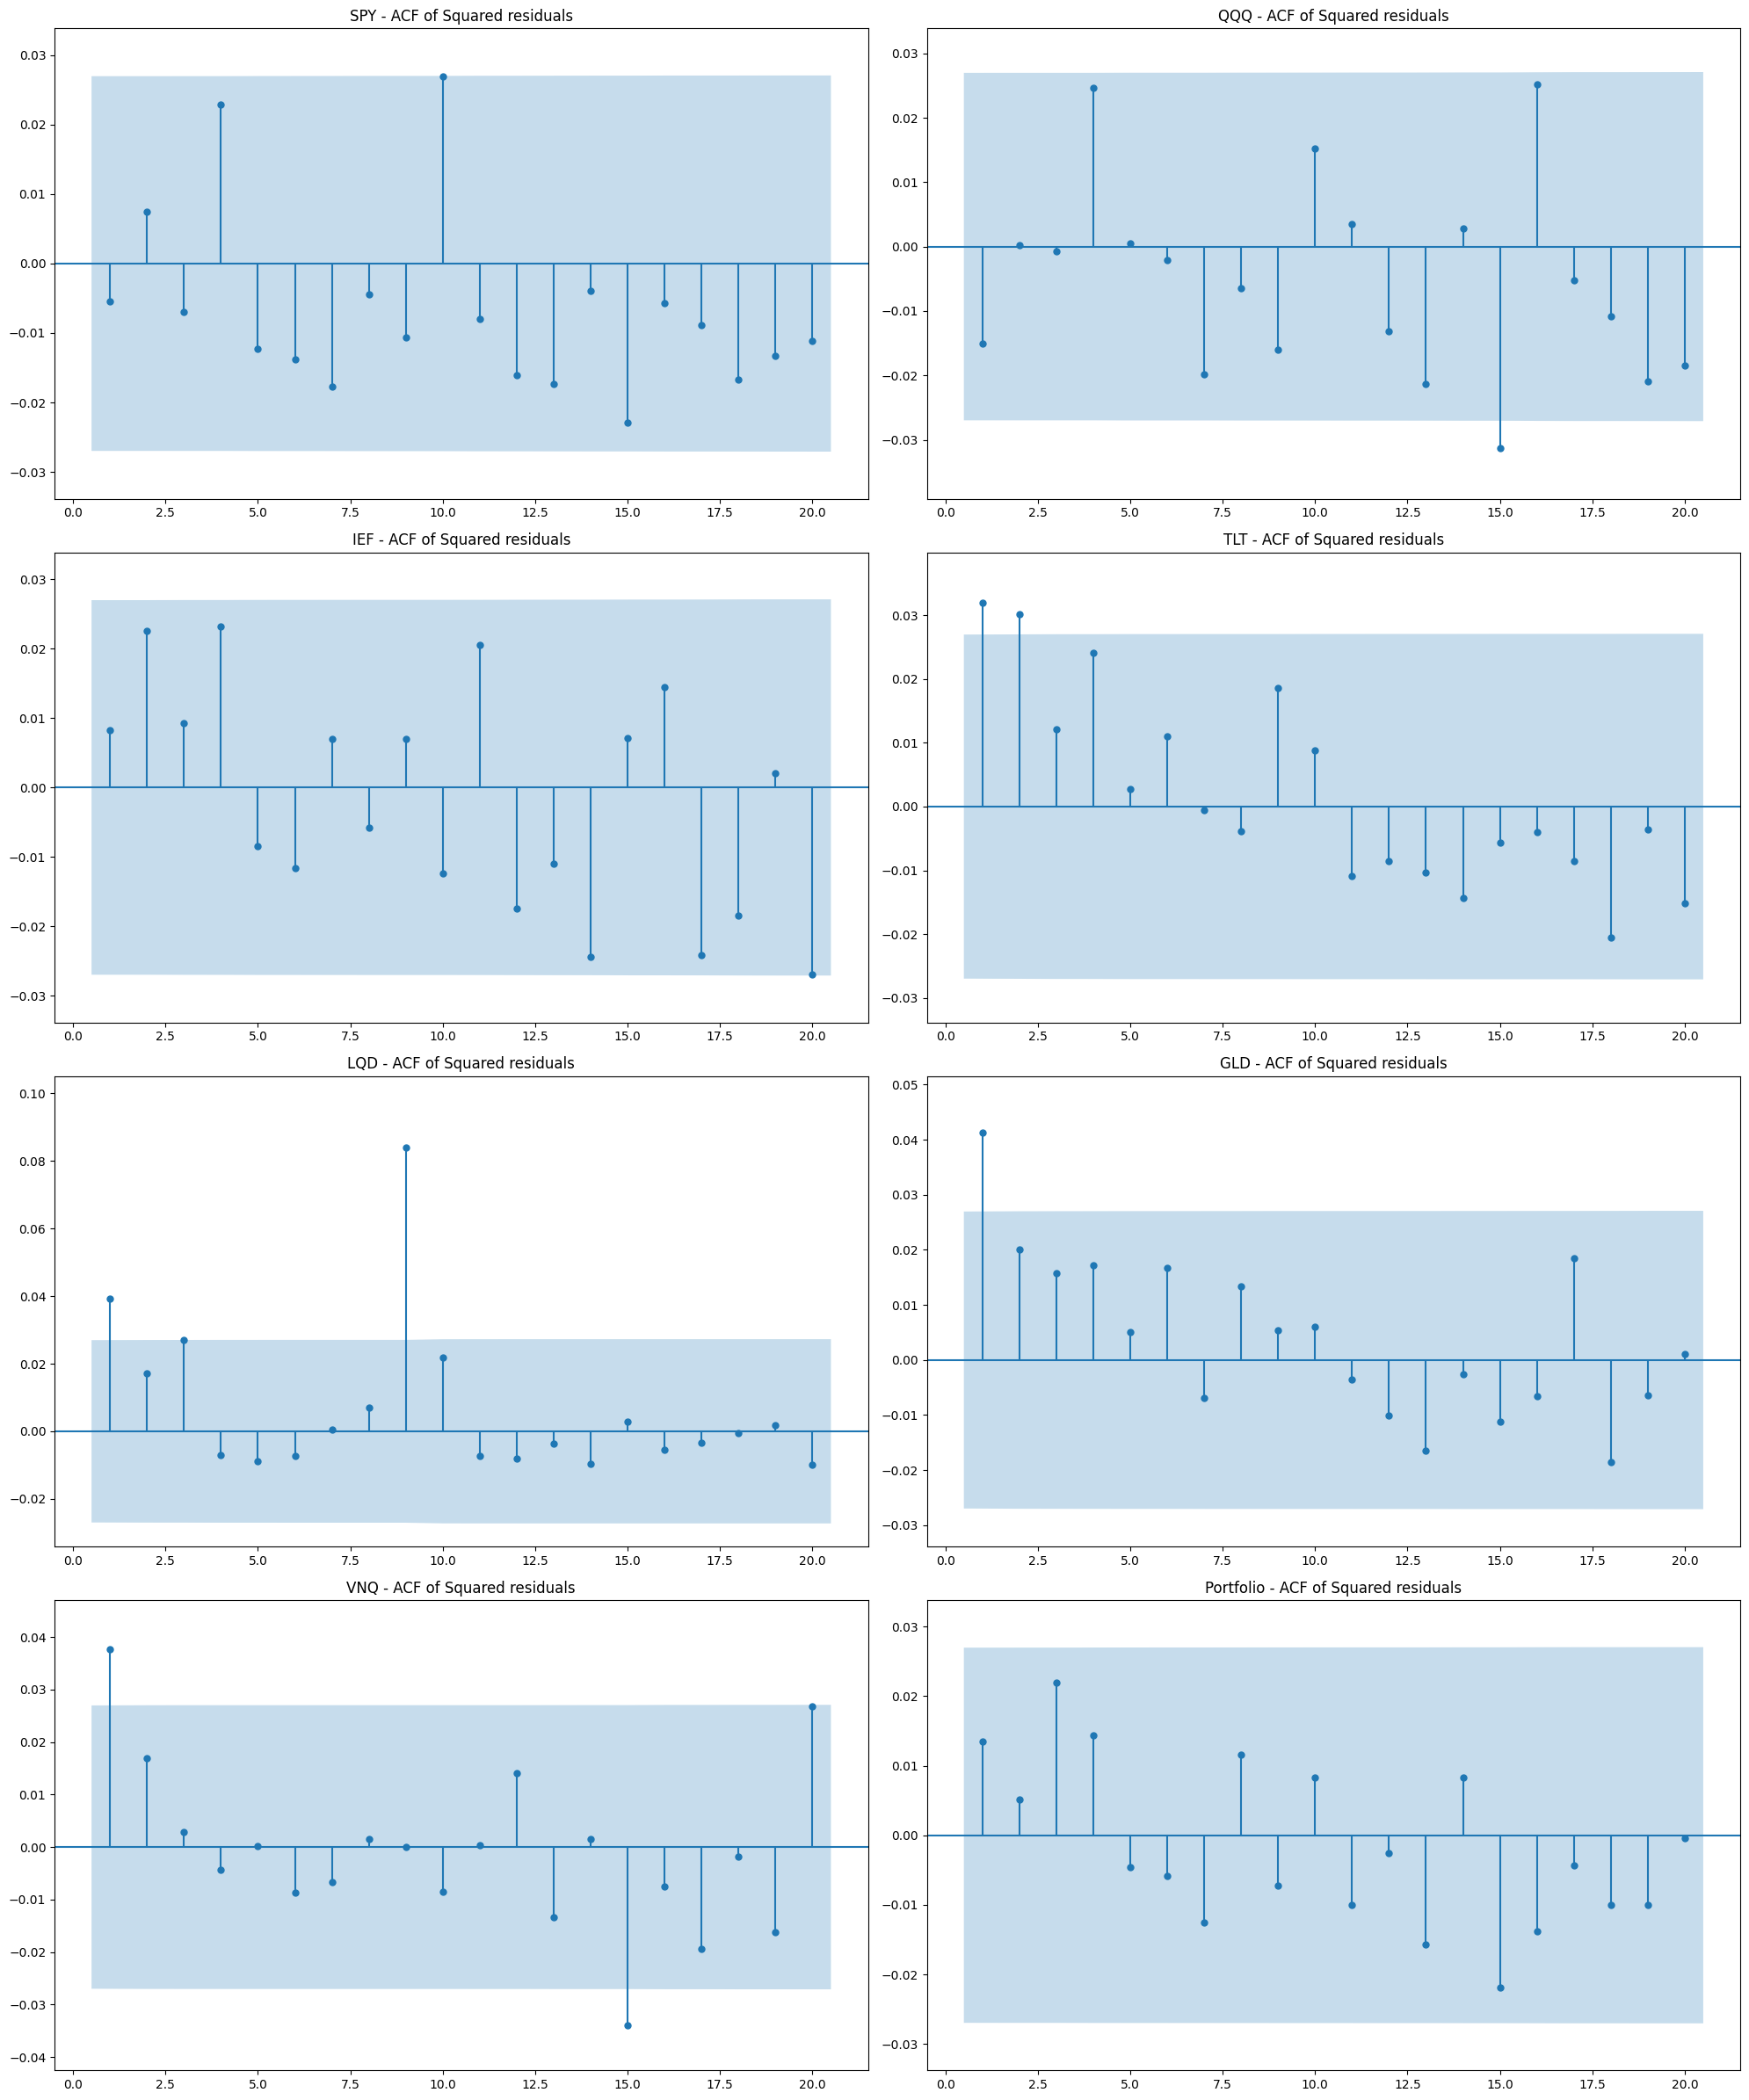

In [82]:
# ACF plots
from statsmodels.graphics.tsaplots import plot_acf

tested_cols = [col for col in tested_res.keys()]
fig, ax = plt.subplots(4,2, figsize=(20,24))
for i, a in enumerate(ax.flat):
    if i >= len(tested_cols):
        break
    res = tested_res[tested_cols[i]]
    std_resid = res.std_resid.dropna()
    plot_acf(std_resid**2, lags=20, zero=False, auto_ylims=True, ax=a, title=f"{tested_cols[i]} - ACF of Squared residuals")
    
plt.tight_layout()

### GARCH or GJR-GARCH for equity assets?

We use AIC/BIC to select which volatility model to use for equity assets (SPY/QQQ/VNQ).

By the following results, we prefer GJR-GARCH for volatility modeling of these assets.

In [83]:
compare_rows = []

for ticker in leverage_assets:
    res_garch  = garch_res[ticker]
    res_gjr = gjr_res[ticker]
    compare_rows.append({
        'Asset'       : ticker,
        'GARCH_AIC'   : round(res_garch.aic, 2),
        'GJR_AIC'     : round(res_gjr.aic, 2),
        'GARCH_BIC'   : round(res_garch.bic, 2),
        'GJR _BIC'     : round(res_gjr.bic, 2),
        'Prefer GJR?' : 'Yes' if res_gjr.aic < res_garch.aic else 'No',
        'Gamma_pval'   : round(gjr_params[ticker]['gamma_pval'], 4)
    })

comparison_df = pd.DataFrame(compare_rows).set_index('Asset')
print(comparison_df.to_string())
#comparison_df.to_csv('../outputs/garch_gjr_comparison.csv')

       GARCH_AIC   GJR_AIC  GARCH_BIC  GJR _BIC Prefer GJR?  Gamma_pval
Asset                                                                  
SPY     37995.78  37807.23   38028.64  37846.66         Yes         0.0
QQQ     40470.82  40320.13   40503.68  40359.56         Yes         0.0
VNQ     41089.06  41061.14   41121.92  41100.57         Yes         0.0


## 5. Final volatility forecast

- Moving Average (window = 252 trading days)
- EWMA (no rolling windows needed since it doesn't have to reestimate parameters)
- GARCH / GJR-GARCH    (window = 504 trading days)

In [54]:
# Moving Average
window = 252
roll_std_252 = returns.rolling(window).std() * np.sqrt(252)  # annualized volatility
roll_std_252

,SPY,QQQ,IEF,TLT,LQD,GLD,VNQ,Portfolio
Date,,,,,,,,
2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2025-12-23,0.193684,0.234422,0.056382,0.119706,0.066372,0.192762,0.170820,0.104494
2025-12-24,0.193376,0.234297,0.056328,0.119724,0.066370,0.192688,0.170136,0.104210
2025-12-26,0.193304,0.234127,0.056129,0.119404,0.066293,0.192799,0.170097,0.104211


In [55]:
# EWMA
roll_ewma

,SPY,QQQ,IEF,TLT,LQD,GLD,VNQ,Portfolio
Date,,,,,,,,
2005-01-04,0.195175,0.292040,0.099157,0.167243,0.089347,0.103658,0.240395,0.172495
2005-01-05,0.195175,0.292040,0.099157,0.167243,0.089347,0.103658,0.240395,0.172495
2005-01-06,0.191135,0.284170,0.096351,0.163472,0.086682,0.100702,0.267588,0.168487
2005-01-07,0.186359,0.276183,0.093488,0.158514,0.084087,0.108654,0.261147,0.163362
2005-01-10,0.180767,0.268532,0.090697,0.153936,0.081544,0.109184,0.253341,0.158398
...,...,...,...,...,...,...,...,...
2025-12-23,0.117252,0.173155,0.036657,0.076526,0.045097,0.172251,0.102510,0.068726
2025-12-24,0.115055,0.168860,0.035577,0.074456,0.043895,0.174674,0.099422,0.067831
2025-12-26,0.112382,0.164109,0.035942,0.075911,0.045170,0.170117,0.099707,0.066840


In [71]:
# Rolling GARCH / GJR-GARCH

def fit_final_garch(returns_df, forecast_horizon=1):
    returns_scaled = returns_df * 1000   # Scale up for numerical stability during GARCH model fitting
    garch_res = {}
    vol_forecasts = {}
    mean_forecasts = {}
    for col in returns_df.columns:
        if col in ['SPY','QQQ','VNQ']:
            model = arch_model(returns_scaled[col], mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="StudentsT", rescale=False)  # Fit GJR-GARCH to equity asset returns
        else:
            model = arch_model(returns_scaled[col], mean="Constant", vol="GARCH", p=1, q=1, dist="StudentsT", rescale=False)
        res = model.fit(disp="off", show_warning=False)
        # Store results
        garch_res[col] = res
        vol_forecasts[col] = np.sqrt(res.forecast(horizon=forecast_horizon).variance.values[-1,:]) / 1000  # rescaled
        mean_forecasts[col] = res.forecast(horizon=forecast_horizon).mean.values[-1,:] / 1000  # rescaled
    return garch_res, vol_forecasts, mean_forecasts

# Rolling window estimation and forecast (one-day-ahead) (not annualized)
window = 504
roll_garch_res = [None]*len(returns)
roll_garch_vol = {col: [np.nan]*len(returns) for col in columns}
roll_garch_mean = {col: [np.nan]*len(returns) for col in columns}
for i in range(window, len(returns)):
    returns_df = returns[i-window:i]
    garch_res, vol_fore, mean_fore = fit_final_garch(returns_df, forecast_horizon=1)
    roll_garch_res[i] = garch_res
    for col in columns:
        roll_garch_vol[col][i] = vol_fore[col][0]
        roll_garch_mean[col][i] = mean_fore[col][0]
    if (i-window) % 100 == 0:
        print(f"window {i-window} GARCH estimation complete")

roll_garch_vol = pd.DataFrame(roll_garch_vol, index=returns.index)
roll_garch_mean = pd.DataFrame(roll_garch_mean, index=returns.index)
roll_garch_vol

window 0 GARCH estimation complete
window 100 GARCH estimation complete
window 200 GARCH estimation complete
window 300 GARCH estimation complete
window 400 GARCH estimation complete
window 500 GARCH estimation complete
window 600 GARCH estimation complete
window 700 GARCH estimation complete
window 800 GARCH estimation complete
window 900 GARCH estimation complete
window 1000 GARCH estimation complete
window 1100 GARCH estimation complete
window 1200 GARCH estimation complete
window 1300 GARCH estimation complete
window 1400 GARCH estimation complete
window 1500 GARCH estimation complete
window 1600 GARCH estimation complete
window 1700 GARCH estimation complete
window 1800 GARCH estimation complete
window 1900 GARCH estimation complete
window 2000 GARCH estimation complete
window 2100 GARCH estimation complete
window 2200 GARCH estimation complete
window 2300 GARCH estimation complete
window 2400 GARCH estimation complete
window 2500 GARCH estimation complete
window 2600 GARCH estima

,SPY,QQQ,IEF,TLT,LQD,GLD,VNQ,Portfolio
Date,,,,,,,,
2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2025-12-23,0.007801,0.011916,0.002581,0.005433,0.003859,0.009895,0.009085,0.004987
2025-12-24,0.007353,0.011274,0.002546,0.005348,0.003780,0.010114,0.008939,0.004915
2025-12-26,0.006982,0.010773,0.002541,0.005379,0.003853,0.009838,0.008899,0.004855


In [73]:
# Save output
roll_std_252.to_csv("../outputs/roll_std_252.csv", index=True)

roll_ewma.to_csv("../outputs/roll_ewma.csv", index=True)

roll_garch_vol.to_csv("../outputs/roll_garch_vol.csv")
roll_garch_mean.to_csv("../outputs/roll_garch_mean.csv")
with open("../outputs/roll_garch_res.pkl", 'wb') as f:
    pickle.dump(roll_garch_res, f)